In [1]:
import pandas as pd

USGS

In [2]:
df = pd.read_csv('data/USGS_data.csv')
df.index = pd.to_datetime(df['DateTime'])
df.drop(columns=['DateTime'], inplace=True)


NLRDB

In [3]:
df2 = pd.read_csv('data/NLRDB_combined.csv')
df2.index = pd.to_datetime(df2['DateTime'])


Combine

In [4]:
# Combine dfs based on index, fill unknown rows with nan
df_combined = pd.concat([df, df2], axis=1)

C:\Users\epzausch\AppData\Local\Temp\ipykernel_25780\3956496792.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_combined = pd.concat([df, df2], axis=1)


In [5]:
# only keep data post 2018, pre 2025
df_combined = df_combined.loc['2018-01-01':'2024-12-31']
df_combined

,Discharge (cfs),Water Temperature (C),pH (std units),Dissolved Oxygen (mg/L),Specific Conductance (uS/cm),Turbidity (NTU),Year,Month,Day,Hour,...,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,DateTime,Smooth Wind Direction
DateTime,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,77.6,12.3,7.2,10.6,401.0,NaN,2018.0,1.0,1.0,0.0,...,71.11,170.93,0.95,0.14,1030.0,1.0,3.0,3.4,2018-01-01 00:00:00,0.052336
2018-01-01 00:15:00,77.6,12.3,7.2,10.5,404.0,NaN,2018.0,1.0,1.0,0.0,...,71.62,172.52,0.95,0.14,1030.0,1.0,4.0,3.4,2018-01-01 00:15:00,0.069756
2018-01-01 00:30:00,77.6,12.3,7.2,10.5,400.0,NaN,2018.0,1.0,1.0,0.0,...,72.14,172.80,0.95,0.14,1030.0,1.0,5.0,3.4,2018-01-01 00:30:00,0.087156
2018-01-01 00:45:00,77.6,12.2,7.2,10.4,400.0,NaN,2018.0,1.0,1.0,0.0,...,68.45,171.61,0.95,0.14,1030.0,1.0,6.0,3.4,2018-01-01 00:45:00,0.104528
2018-01-01 01:00:00,77.6,12.2,7.2,10.4,399.0,NaN,2018.0,1.0,1.0,1.0,...,68.94,169.46,0.95,0.14,1030.0,1.0,7.0,3.4,2018-01-01 01:00:00,0.121869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,272.0,18.9,7.5,8.6,219.0,103.0,2024.0,12.0,31.0,22.0,...,100.00,156.63,0.95,0.15,1016.0,2.1,191.0,1.1,2024-12-31 22:45:00,-0.190809
2024-12-31 23:00:00,272.0,18.8,7.5,8.6,220.0,102.0,2024.0,12.0,31.0,23.0,...,100.00,159.78,0.95,0.15,1016.0,2.1,193.0,1.1,2024-12-31 23:00:00,-0.224951
2024-12-31 23:15:00,269.0,18.7,7.4,8.6,222.0,102.0,2024.0,12.0,31.0,23.0,...,100.00,162.87,0.95,0.15,1016.0,2.1,195.0,1.1,2024-12-31 23:15:00,-0.258819


In [9]:
import matplotlib.pyplot as plt

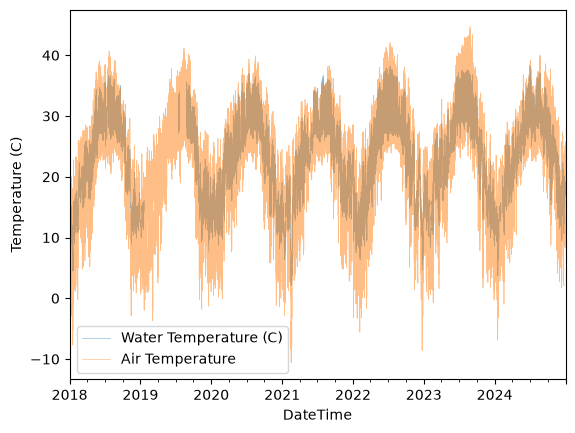

In [11]:
df_combined['Water Temperature (C)'].plot(linewidth=0.5, alpha = 0.5)
df_combined['Air Temperature'].plot(linewidth=0.5, alpha = 0.5)
plt.ylabel("Temperature (C)")
plt.legend()

<Axes: xlabel='DateTime'>

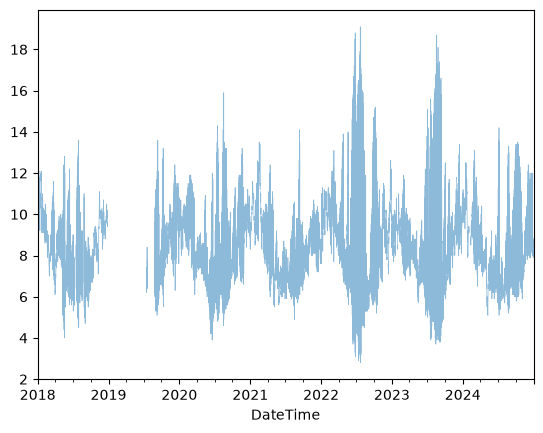

In [7]:
df_combined['Dissolved Oxygen (mg/L)'].plot(linewidth=0.5, alpha = 0.5)

<Axes: xlabel='DateTime'>

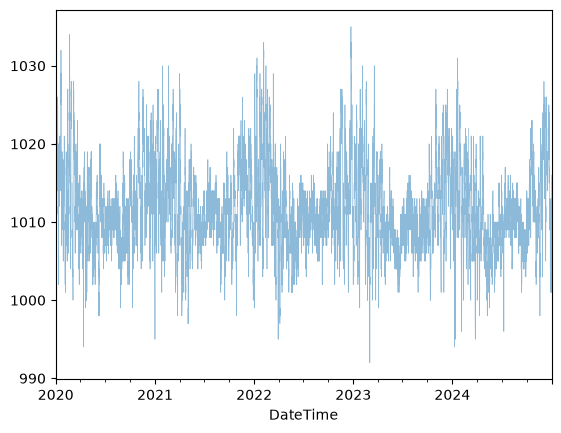

In [14]:
df_combined['Pressure'].plot(linewidth=0.5, alpha = 0.5)

In [15]:
df_combined.columns

Index(['Discharge (cfs)', 'Water Temperature (C)', 'pH (std units)',
       'Dissolved Oxygen (mg/L)', 'Specific Conductance (uS/cm)',
       'Turbidity (NTU)', 'Year', 'Month', 'Day', 'Hour', 'Minute',
       'Air Temperature', 'Alpha', 'Aerosol Optical Depth', 'Asymmetry',
       'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Fill Flag',
       'Cloud Type', 'Dew Point', 'DHI', 'DNI', 'Fill Flag', 'GHI', 'Ozone',
       'Relative Humidity', 'Solar Zenith Angle', 'SSA', 'Surface Albedo',
       'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed',
       'DateTime', 'Smooth Wind Direction'],
      dtype='str')

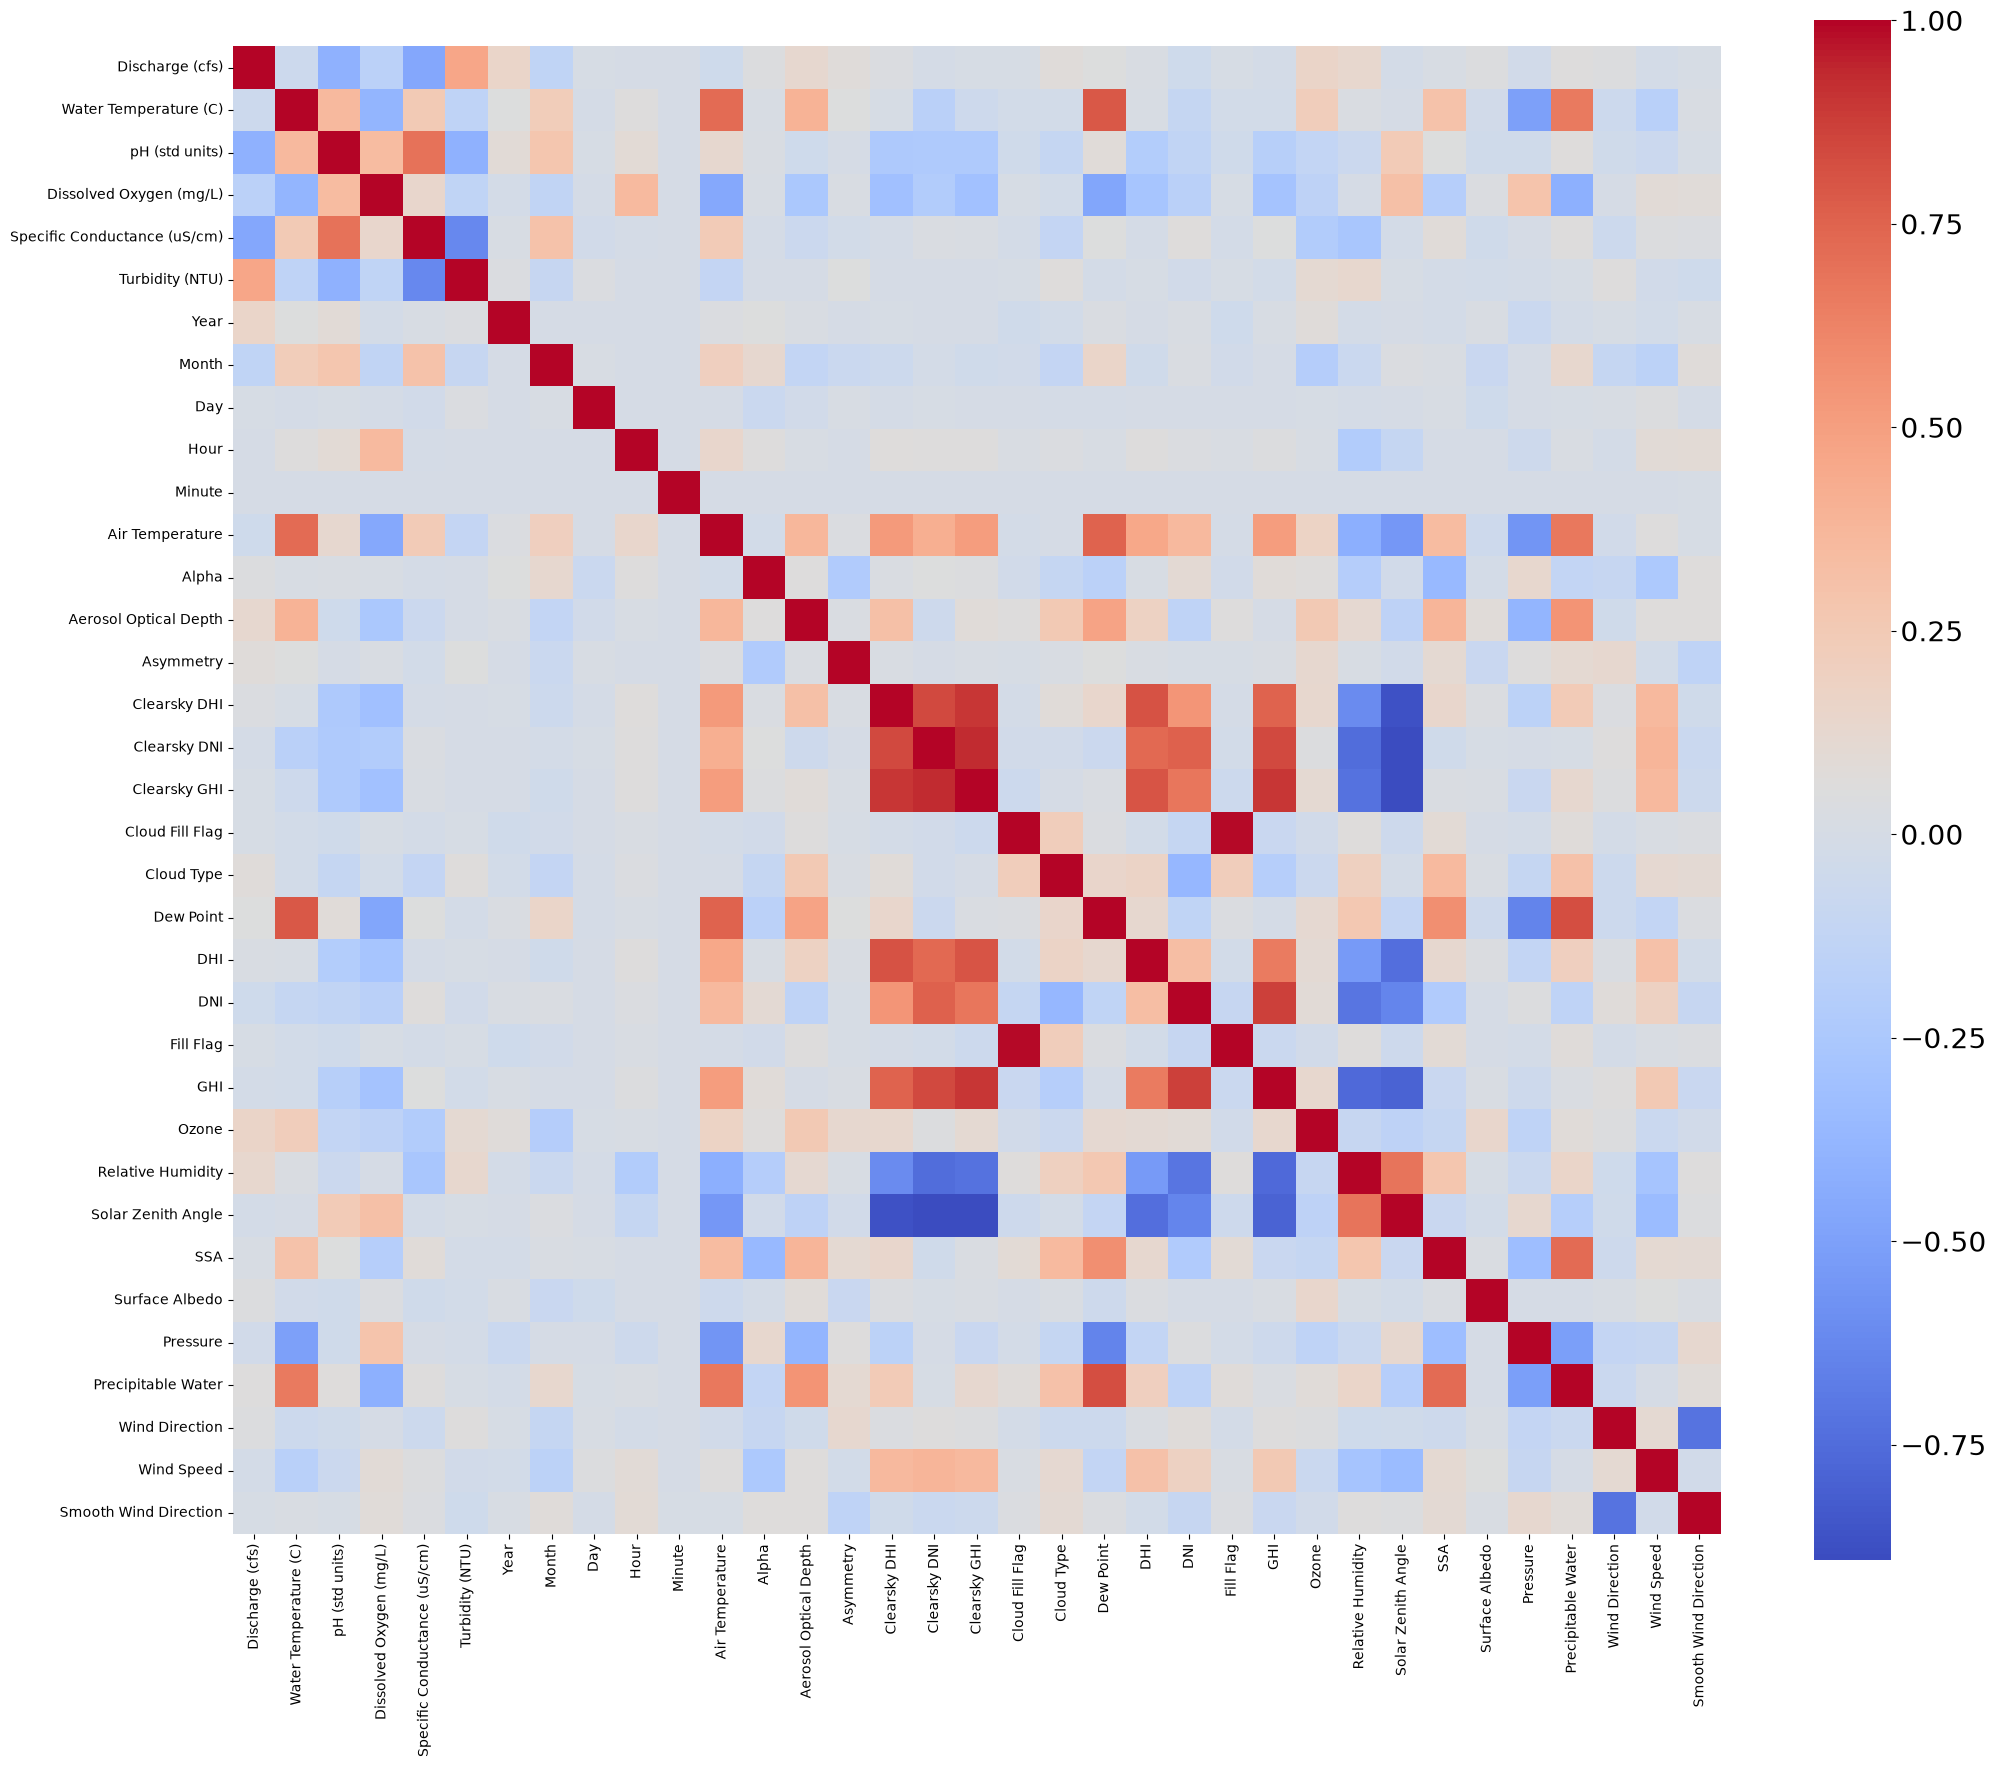

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(24,20))
num_cols = df_combined.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
# num_cols = num_cols.append(merged.columns[-1:])
corr = df_combined[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=False, cmap="coolwarm",ax=ax)
ax.set_aspect(1)